In [ ]:
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
import numpy as np

data = fetch_olivetti_faces()

X = data.images       # shape: (400, 64, 64) - 400 face images, 64x64 pixels each
y = data.target        # shape: (400,) - person ID for each image (0 to 39)

print("Total images:", X.shape[0])
print("Image size:", X.shape[1], "x", X.shape[2])
print("Number of unique people:", len(np.unique(y)))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Total images: 400
Image size: 64 x 64
Number of unique people: 40


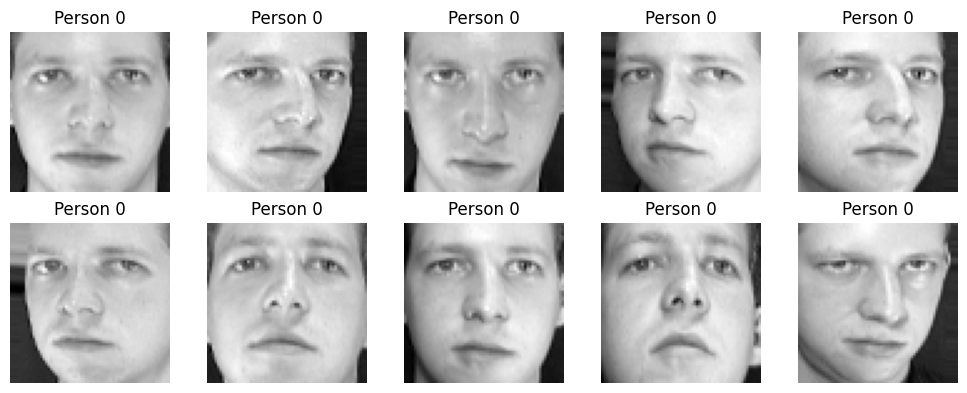

In [ ]:
# Visualize a few images to see what we're working with
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(f"Person {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

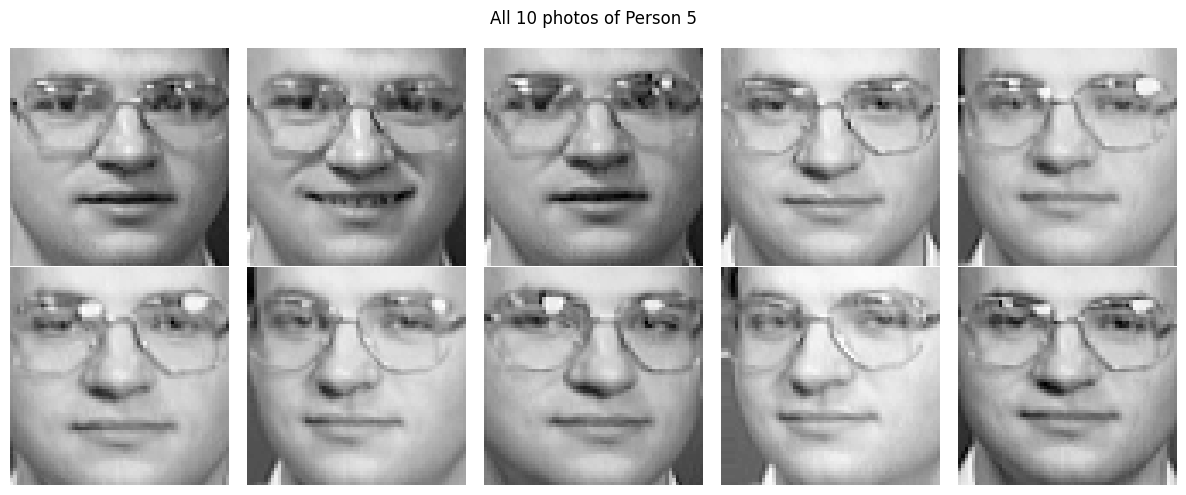

In [ ]:
# See all 10 photos of ONE specific person, to see the natural variation
person_id = 5
person_images = X[y == person_id]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(person_images[i], cmap='gray')
    ax.axis('off')
plt.suptitle(f"All 10 photos of Person {person_id}")
plt.tight_layout()
plt.show()

In [ ]:
import cv2

# OpenCV ships with pretrained Haar Cascade files built in
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [ ]:
# Olivetti images are stored as float values between 0 and 1 - Haar Cascade needs 0-255 integers
sample_image = (X[0] * 255).astype('uint8')

faces_found = face_cascade.detectMultiScale(sample_image, scaleFactor=1.1, minNeighbors=5)

print("Number of faces detected:", len(faces_found))
print("Face location (x, y, width, height):", faces_found)

Number of faces detected: 0
Face location (x, y, width, height): ()


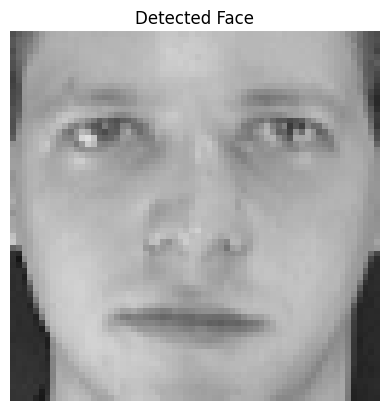

In [ ]:
import matplotlib.pyplot as plt

image_with_box = cv2.cvtColor(sample_image, cv2.COLOR_GRAY2BGR)

for (x, y, w, h) in faces_found:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(image_with_box)
plt.title("Detected Face")
plt.axis('off')
plt.show()

In [ ]:
detected_count = 0
missed_count = 0

for img in X:
    img_uint8 = (img * 255).astype('uint8')
    faces = face_cascade.detectMultiScale(img_uint8, scaleFactor=1.1, minNeighbors=5)
    if len(faces) > 0:
        detected_count += 1
    else:
        missed_count += 1

print(f"Faces detected: {detected_count}/400")
print(f"Faces missed: {missed_count}/400")

Faces detected: 2/400
Faces missed: 398/400


In [ ]:
print("Current image shape:", X.shape)
print("Pixel value range:", X.min(), "to", X.max())

Current image shape: (400, 64, 64)
Pixel value range: 0.0 to 1.0


In [ ]:
import cv2

def preprocess_face(image, target_size=(64, 64)):
    # Resize to a consistent size
    resized = cv2.resize(image, target_size)
    # Normalize pixel values to 0-1 range
    normalized = resized.astype('float32') / 255.0
    return normalized

# Example: simulate what this would do to a raw 0-255 image
sample_raw = (X[0] * 255).astype('uint8')   # pretend this is a fresh webcam capture
processed = preprocess_face(sample_raw)

print("Processed shape:", processed.shape)
print("Processed range:", processed.min(), "to", processed.max())

Processed shape: (64, 64)
Processed range: 0.08235294 to 0.8745098


In [ ]:
!pip install face_recognition -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import face_recognition
import numpy as np

# face_recognition expects standard 0-255 RGB images, not grayscale 0-1 floats
sample_uint8 = (X[0] * 255).astype('uint8')
sample_rgb = cv2.cvtColor(sample_uint8, cv2.COLOR_GRAY2RGB)   # convert grayscale to 3-channel

encodings = face_recognition.face_encodings(sample_rgb)

if len(encodings) > 0:
    embedding = encodings[0]
    print("Embedding length:", len(embedding))
    print("First 10 values:", embedding[:10])
else:
    print("No face found in this image")

Embedding length: 128
First 10 values: [-0.10009742  0.06964251 -0.016606   -0.05337643 -0.10059583 -0.04707346
 -0.0056905  -0.07076836  0.14473365 -0.0292439 ]


In [ ]:
embeddings_list = []
labels_list = []
failed_indices = []

for i in range(len(X)):
    img_uint8 = (X[i] * 255).astype('uint8')
    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)

    encodings = face_recognition.face_encodings(img_rgb)

    if len(encodings) > 0:
        embeddings_list.append(encodings[0])
        labels_list.append(y[i])
    else:
        failed_indices.append(i)

embeddings_array = np.array(embeddings_list)
labels_array = np.array(labels_list)

print("Successfully extracted embeddings:", embeddings_array.shape)
print("Failed on", len(failed_indices), "images")

Successfully extracted embeddings: (311, 128)
Failed on 89 images


In [ ]:
import numpy as np

unique_labels, counts = np.unique(labels_array, return_counts=True)

print("People with fewer than 2 successful embeddings:")
for label, count in zip(unique_labels, counts):
    if count < 2:
        print(f"  Person {label}: only {count} embedding(s)")

print("\nTotal people with enough data:", np.sum(counts >= 2))
print("Total people with too little data:", np.sum(counts < 2))

People with fewer than 2 successful embeddings:
  Person 1: only 1 embedding(s)
  Person 36: only 1 embedding(s)

Total people with enough data: 37
Total people with too little data: 2


In [ ]:
# Keep only people with at least 2 successful embeddings
valid_labels = unique_labels[counts >= 2]
mask = np.isin(labels_array, valid_labels)

embeddings_array_clean = embeddings_array[mask]
labels_array_clean = labels_array[mask]

print("Before cleaning:", embeddings_array.shape[0], "embeddings,", len(unique_labels), "people")
print("After cleaning:", embeddings_array_clean.shape[0], "embeddings,", len(valid_labels), "people")

Before cleaning: 311 embeddings, 39 people
After cleaning: 309 embeddings, 37 people


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings_array_clean, labels_array_clean, test_size=0.2, random_state=42, stratify=labels_array_clean
)

print("Training embeddings:", X_train.shape)
print("Testing embeddings:", X_test.shape)

Training embeddings: (247, 128)
Testing embeddings: (62, 128)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# KNN
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_preds))

# SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))

KNN Accuracy: 1.0
SVM Accuracy: 0.9838709677419355


In [ ]:
print("=== KNN Results ===")
print(classification_report(y_test, knn_preds))

print("\n=== SVM Results ===")
print(classification_report(y_test, svm_preds))

=== KNN Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         2
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def capture_photo(filename='photo.jpg'):
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';
            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', 0.9);
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    img = cv2.imread(filename)
    return img

In [ ]:
import face_recognition
import pickle
import os

DATABASE_FILE = "known_faces.pkl"

def load_database():
    if os.path.exists(DATABASE_FILE):
        with open(DATABASE_FILE, 'rb') as f:
            return pickle.load(f)
    return {"names": [], "embeddings": []}

def save_database(database):
    with open(DATABASE_FILE, 'wb') as f:
        pickle.dump(database, f)

def register_new_person(name, num_photos=3):
    database = load_database()

    print(f"Registering {name}. We'll take {num_photos} photos.")
    for i in range(num_photos):
        print(f"\nPhoto {i+1}/{num_photos} - click Capture when ready")
        img = capture_photo(f"reg_{name}_{i}.jpg")

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        encodings = face_recognition.face_encodings(img_rgb)

        if len(encodings) > 0:
            database["names"].append(name)
            database["embeddings"].append(encodings[0])
            print(f"Face captured successfully for {name}")
        else:
            print("No face detected in this photo, try again")

    save_database(database)
    print(f"\n{name} registered with {database['names'].count(name)} total photo(s) in database")

In [ ]:
register_new_person("Uday", num_photos=3)

Registering Uday. We'll take 3 photos.

Photo 1/3 - click Capture when ready


<IPython.core.display.Javascript object>

Face captured successfully for Uday

Photo 2/3 - click Capture when ready


<IPython.core.display.Javascript object>

Face captured successfully for Uday

Photo 3/3 - click Capture when ready


<IPython.core.display.Javascript object>

Face captured successfully for Uday

Uday registered with 3 total photo(s) in database


In [ ]:
import numpy as np

def recognize_face(image_rgb, database, tolerance=0.6):
    encodings = face_recognition.face_encodings(image_rgb)

    if len(encodings) == 0:
        return None, None

    new_embedding = encodings[0]

    known_embeddings = np.array(database["embeddings"])
    distances = face_recognition.face_distance(known_embeddings, new_embedding)

    best_match_index = np.argmin(distances)
    best_distance = distances[best_match_index]

    if best_distance <= tolerance:
        matched_name = database["names"][best_match_index]
        confidence = 1 - best_distance
        return matched_name, confidence
    else:
        return "Unknown", 1 - best_distance

In [ ]:
import pandas as pd
from datetime import datetime

ATTENDANCE_FILE = "attendance.csv"

def mark_attendance(name):
    if os.path.exists(ATTENDANCE_FILE):
        df = pd.read_csv(ATTENDANCE_FILE)
    else:
        df = pd.DataFrame(columns=["Name", "Date", "Time"])

    now = datetime.now()
    today = now.strftime("%Y-%m-%d")

    already_marked = ((df["Name"] == name) & (df["Date"] == today)).any()

    if already_marked:
        print(f"{name} is already marked present today.")
    else:
        new_entry = pd.DataFrame([{
            "Name": name,
            "Date": today,
            "Time": now.strftime("%H:%M:%S")
        }])
        df = pd.concat([df, new_entry], ignore_index=True)
        df.to_csv(ATTENDANCE_FILE, index=False)
        print(f"Attendance marked for {name} at {now.strftime('%H:%M:%S')}")

In [ ]:
def take_attendance():
    database = load_database()

    if len(database["names"]) == 0:
        print("No one is registered yet!")
        return

    print("Look at the camera and click Capture")
    img = capture_photo("attendance_check.jpg")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    name, confidence = recognize_face(img_rgb, database)

    if name is None:
        print("No face detected in the photo. Try again.")
    elif name == "Unknown":
        print(f"Face not recognized (closest match confidence too low: {confidence:.2f}). Not marking attendance.")
    else:
        print(f"Recognized: {name} (confidence: {confidence:.2f})")
        mark_attendance(name)

In [ ]:
take_attendance()

Look at the camera and click Capture


<IPython.core.display.Javascript object>

Recognized: Uday (confidence: 0.86)
Attendance marked for Uday at 18:16:11


In [ ]:
import pandas as pd
pd.read_csv("attendance.csv")

,Name,Date,Time
0,Uday,2026-07-21,18:16:11


In [ ]:
%%writefile attendance_app.py
import streamlit as st
import face_recognition
import numpy as np
import pandas as pd
import pickle
import os
import cv2
from datetime import datetime
from PIL import Image

DATABASE_FILE = "known_faces.pkl"
ATTENDANCE_FILE = "attendance.csv"

# ---------- Helper functions (same logic as before) ----------

def load_database():
    if os.path.exists(DATABASE_FILE):
        with open(DATABASE_FILE, 'rb') as f:
            return pickle.load(f)
    return {"names": [], "embeddings": []}

def save_database(database):
    with open(DATABASE_FILE, 'wb') as f:
        pickle.dump(database, f)

def mark_attendance(name):
    if os.path.exists(ATTENDANCE_FILE):
        df = pd.read_csv(ATTENDANCE_FILE)
    else:
        df = pd.DataFrame(columns=["Name", "Date", "Time"])

    now = datetime.now()
    today = now.strftime("%Y-%m-%d")
    already_marked = ((df["Name"] == name) & (df["Date"] == today)).any()

    if already_marked:
        return f"{name} is already marked present today."
    else:
        new_entry = pd.DataFrame([{"Name": name, "Date": today, "Time": now.strftime("%H:%M:%S")}])
        df = pd.concat([df, new_entry], ignore_index=True)
        df.to_csv(ATTENDANCE_FILE, index=False)
        return f"Attendance marked for {name} at {now.strftime('%H:%M:%S')}"

def recognize_face(image_rgb, database, tolerance=0.6):
    encodings = face_recognition.face_encodings(image_rgb)
    if len(encodings) == 0:
        return None, None
    new_embedding = encodings[0]
    known_embeddings = np.array(database["embeddings"])
    distances = face_recognition.face_distance(known_embeddings, new_embedding)
    best_match_index = np.argmin(distances)
    best_distance = distances[best_match_index]
    if best_distance <= tolerance:
        return database["names"][best_match_index], 1 - best_distance
    else:
        return "Unknown", 1 - best_distance

# ---------- Streamlit UI ----------

st.set_page_config(page_title="Face Recognition Attendance", page_icon="🎓", layout="wide")
st.title("🎓 Face Recognition Attendance System")

tab1, tab2, tab3 = st.tabs(["📸 Take Attendance", "➕ Register New Person", "📊 Attendance Dashboard"])

# --- TAB 1: Take Attendance ---
with tab1:
    st.header("Mark Attendance")
    database = load_database()

    if len(database["names"]) == 0:
        st.warning("No one is registered yet. Go to the 'Register New Person' tab first.")
    else:
        camera_photo = st.camera_input("Look at the camera and take a photo")

        if camera_photo is not None:
            img = Image.open(camera_photo)
            img_rgb = np.array(img.convert("RGB"))

            name, confidence = recognize_face(img_rgb, database)

            if name is None:
                st.error("No face detected. Please try again.")
            elif name == "Unknown":
                st.error(f"Face not recognized (confidence too low: {confidence:.2f}). Attendance not marked.")
            else:
                st.success(f"Recognized: **{name}** (confidence: {confidence:.2f})")
                result = mark_attendance(name)
                st.info(result)

# --- TAB 2: Register New Person ---
with tab2:
    st.header("Register a New Person")
    new_name = st.text_input("Enter the person's name:")
    reg_photo = st.camera_input("Take a clear photo of their face")

    if st.button("Register"):
        if new_name.strip() == "":
            st.warning("Please enter a name first.")
        elif reg_photo is None:
            st.warning("Please take a photo first.")
        else:
            img = Image.open(reg_photo)
            img_rgb = np.array(img.convert("RGB"))
            encodings = face_recognition.face_encodings(img_rgb)

            if len(encodings) == 0:
                st.error("No face detected in the photo. Try again with better lighting.")
            else:
                database = load_database()
                database["names"].append(new_name)
                database["embeddings"].append(encodings[0])
                save_database(database)
                st.success(f"{new_name} registered successfully!")

# --- TAB 3: Dashboard ---
with tab3:
    st.header("Attendance Records")

    if os.path.exists(ATTENDANCE_FILE):
        df = pd.read_csv(ATTENDANCE_FILE)

        col1, col2 = st.columns(2)
        with col1:
            selected_date = st.date_input("Filter by date", value=None)
        with col2:
            selected_name = st.selectbox("Filter by name", options=["All"] + sorted(df["Name"].unique().tolist()))

        filtered_df = df.copy()
        if selected_date:
            filtered_df = filtered_df[filtered_df["Date"] == str(selected_date)]
        if selected_name != "All":
            filtered_df = filtered_df[filtered_df["Name"] == selected_name]

        st.dataframe(filtered_df, use_container_width=True)

        st.subheader("Attendance Count per Person")
        st.bar_chart(df["Name"].value_counts())
    else:
        st.info("No attendance records yet.")

Writing attendance_app.py


In [ ]:
!pkill -f streamlit
!streamlit run attendance_app.py --server.port 8501 &>/content/logs.txt &

import time
time.sleep(6)
!cat /content/logs.txt

/bin/bash: line 1: streamlit: command not found


In [ ]:
from google.colab import files

files.download('attendance_app.py')
files.download('known_faces.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = "/content/drive/MyDrive/face_attendance_project"
os.makedirs(save_path, exist_ok=True)

!cp attendance_app.py {save_path}/attendance_app.py
!cp known_faces.pkl {save_path}/known_faces.pkl

print("Backed up permanently to Drive.")

Mounted at /content/drive
Backed up permanently to Drive.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/face_attendance_project"
!cp {save_path}/attendance_app.py .
!cp {save_path}/known_faces.pkl .

from google.colab import files
files.download('attendance_app.py')
files.download('known_faces.pkl')

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>